In [ ]:
#Mahima
import pandas as pd
import numpy as np
import re
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
import warnings
warnings.filterwarnings('ignore')

class BollywoodDataCleaner:

    def __init__(self, filepath):
        self.df = pd.read_csv(filepath, encoding='utf-8')
        self.original_shape = self.df.shape
        print(f"Loaded dataset: {self.original_shape[0]} rows, {self.original_shape[1]} columns")

    def clean_data(self):
        """Main cleaning pipeline"""
        print("\n=== Starting Data Cleaning ===\n")

        self._handle_duplicates()
        self._clean_release_date()
        self._clean_year()
        self._clean_ratings()
        self._clean_votes()
        self._clean_runtime()
        self._parse_genres()
        self._parse_wins_nominations()
        self._parse_actors()
        self._create_movie_id()
        self._remove_invalid_rows()
        self._create_success_metrics()

        print(f"\n=== Cleaning Complete ===")
        print(f"Final shape: {self.df.shape[0]} rows (removed {self.original_shape[0] - self.df.shape[0]})")

        return self.df

    def _handle_duplicates(self):
        """Remove duplicate movies"""
        before = len(self.df)
        title_col = 'title_x' if 'title_x' in self.df.columns else 'title_y'
        self.df = self.df.drop_duplicates(subset=[title_col, 'year_of_release'], keep='first')
        removed = before - len(self.df)
        print(f"✓ Removed {removed} duplicate movies")

    def _clean_release_date(self):

        def parse_release_date(date_str):
            # Handle missing/blank
            if pd.isnull(date_str) or str(date_str).strip() == '':
                return None, None

            try:
                date_str = str(date_str)

                # Extract country from parentheses if present
                country_match = re.search(r'\(([^)]+)\)', date_str)
                country = country_match.group(1) if country_match else None

                # Remove country part to isolate date
                date_part = re.sub(r'\s*\([^)]+\)', '', date_str).strip()

                # Try different date formats
                date_formats = [
                    '%d %B %Y',      # 11 January 2019
                    '%B %d %Y',      # January 11 2019
                    '%d %b %Y',      # 11 Jan 2019
                    '%Y-%m-%d',      # 2019-01-11
                    '%d-%m-%Y',      # 11-01-2019
                    '%d/%m/%Y',      # 11/01/2019
                ]

                for fmt in date_formats:
                    try:
                        parsed_date = datetime.strptime(date_part, fmt)
                        return parsed_date, country
                    except:
                        continue

                # If no format works, return None
                return None, country

            except Exception as e:
                return None, None

        # Parse dates
        self.df[['release_date_parsed', 'release_country']] = self.df['release_date'].apply(
            lambda x: pd.Series(parse_release_date(x))
        )

        parsed = self.df['release_date_parsed'].notnull().sum()
        missing = len(self.df) - parsed
        india_count = (self.df['release_country'] == 'India').sum()
        usa_count = (self.df['release_country'] == 'USA').sum()
        no_country = self.df['release_country'].isnull().sum()

        print(f"✓ Parsed release dates:")
        print(f"  Successfully parsed: {parsed}/{len(self.df)}")
        print(f"  Missing dates: {missing}")
        print(f"  India releases: {india_count}, USA releases: {usa_count}, No country: {no_country}")

    def _clean_year(self):
        """Clean year_of_release, use parsed date as fallback"""
        self.df['year_of_release'] = pd.to_numeric(self.df['year_of_release'], errors='coerce')

        # Fill missing years from parsed release date if available
        mask = self.df['year_of_release'].isnull() & self.df['release_date_parsed'].notnull()
        filled = mask.sum()
        self.df.loc[mask, 'year_of_release'] = self.df.loc[mask, 'release_date_parsed'].dt.year

        # Filter to valid year range (2000-2023)
        before = len(self.df)
        self.df = self.df[
            (self.df['year_of_release'] >= 2000) &
            (self.df['year_of_release'] <= 2023)
        ]
        removed = before - len(self.df)

        missing = self.df['year_of_release'].isnull().sum()
        print(f"✓ Cleaned year_of_release:")
        print(f"  Filled {filled} years from parsed dates")
        print(f"  Filtered 2000-2023: removed {removed} movies")
        print(f"  Still missing: {missing}")

    def _clean_ratings(self):
        """Clean IMDb ratings"""
        self.df['imdb_rating'] = pd.to_numeric(self.df['imdb_rating'], errors='coerce')

        # IMDb ratings should be 0-10
        invalid = ((self.df['imdb_rating'] < 0) | (self.df['imdb_rating'] > 10)).sum()
        self.df.loc[(self.df['imdb_rating'] < 0) | (self.df['imdb_rating'] > 10), 'imdb_rating'] = np.nan

        missing = self.df['imdb_rating'].isnull().sum()
        avg_rating = self.df['imdb_rating'].mean()

        print(f"✓ Cleaned imdb_rating:")
        print(f"  Invalid values: {invalid}")
        print(f"  Missing: {missing}/{len(self.df)} ({missing/len(self.df)*100:.1f}%)")
        print(f"  Average rating: {avg_rating:.2f}")

    def _clean_votes(self):
        """Clean IMDb votes"""
        # Remove commas if present (e.g., "1,234" -> "1234")
        if self.df['imdb_votes'].dtype == 'object':
            self.df['imdb_votes'] = self.df['imdb_votes'].astype(str).str.replace(',', '').str.replace(' ', '')

        self.df['imdb_votes'] = pd.to_numeric(self.df['imdb_votes'], errors='coerce')

        # Votes should be non-negative
        negative = (self.df['imdb_votes'] < 0).sum()
        self.df.loc[self.df['imdb_votes'] < 0, 'imdb_votes'] = np.nan

        missing = self.df['imdb_votes'].isnull().sum()
        median_votes = self.df['imdb_votes'].median()

        print(f"✓ Cleaned imdb_votes:")
        print(f"  Negative values: {negative}")
        print(f"  Missing: {missing}/{len(self.df)} ({missing/len(self.df)*100:.1f}%)")
        print(f"  Median votes: {median_votes:.0f}")

    def _clean_runtime(self):
        """Clean runtime (in minutes)"""
        self.df['runtime'] = pd.to_numeric(self.df['runtime'], errors='coerce')

        # Reasonable runtime: 60-300 minutes for feature films
        unreasonable = ((self.df['runtime'] < 60) | (self.df['runtime'] > 300)).sum()
        self.df.loc[(self.df['runtime'] < 60) | (self.df['runtime'] > 300), 'runtime'] = np.nan

        missing = self.df['runtime'].isnull().sum()
        avg_runtime = self.df['runtime'].mean()

        print(f"✓ Cleaned runtime:")
        print(f"  Unreasonable values: {unreasonable}")
        print(f"  Missing: {missing}/{len(self.df)}")
        print(f"  Average runtime: {avg_runtime:.0f} minutes")

    def _parse_genres(self):
        """
        Parse genres from pipe-separated format: 'Action|Adventure|Comedy'
        Handle single genres and missing values
        """
        def parse_genre_string(genre_str):
            if pd.isnull(genre_str) or str(genre_str).strip() == '':
                return []

            # Split by pipe and clean whitespace
            genres = [g.strip() for g in str(genre_str).split('|') if g.strip()]
            return genres

        self.df['genres_list'] = self.df['genres'].apply(parse_genre_string)
        self.df['primary_genre'] = self.df['genres_list'].apply(
            lambda x: x[0] if len(x) > 0 else 'Unknown'
        )
        self.df['num_genres'] = self.df['genres_list'].apply(len)

        # Get unique genres
        all_genres = set()
        for genres in self.df['genres_list']:
            all_genres.update(genres)

        print(f"✓ Parsed genres:")
        print(f"  Unique genres: {len(all_genres)}")
        print(f"  Movies with multiple genres: {(self.df['num_genres'] > 1).sum()}")
        print(f"  Top 5 primary genres: {dict(self.df['primary_genre'].value_counts().head(5))}")

    def _parse_wins_nominations(self):
        """
        Extract wins and nominations from formats:
        - '17 wins & 1 nomination'
        - '5 wins'
        - '3 nominations'
        - Empty/blank cell (no awards) -> 0, 0
        """
        def extract_wins_noms(text):
            # Handle empty/blank cells
            if pd.isnull(text) or str(text).strip() == '':
                return 0, 0

            text = str(text).lower()
            wins = 0
            noms = 0

            # Pattern matching for wins and nominations
            win_match = re.search(r'(\d+)\s*wins?', text)
            nom_match = re.search(r'(\d+)\s*nominations?', text)

            if win_match:
                wins = int(win_match.group(1))
            if nom_match:
                noms = int(nom_match.group(1))

            return wins, noms

        self.df[['wins', 'nominations']] = self.df['wins_nominations'].apply(
            lambda x: pd.Series(extract_wins_noms(x))
        )

        self.df['total_recognitions'] = self.df['wins'] + self.df['nominations']

        movies_with_awards = (self.df['total_recognitions'] > 0).sum()
        movies_blank = (self.df['wins_nominations'].isnull() | (self.df['wins_nominations'].astype(str).str.strip() == '')).sum()

        print(f"✓ Parsed wins & nominations:")
        print(f"  Movies with awards: {movies_with_awards}/{len(self.df)}")
        print(f"  Blank award cells: {movies_blank}")
        print(f"  Total wins: {self.df['wins'].sum()}")
        print(f"  Total nominations: {self.df['nominations'].sum()}")

    def _parse_actors(self):
        """
        Parse actors from pipe-separated format: 'Actor1|Actor2|Actor3|...'
        Actors are already properly formatted (First Last, Title Case)
        Can be many actors (10-15+), not just 5
        """
        def parse_actor_string(actor_str):
            if pd.isnull(actor_str) or str(actor_str).strip() == '':
                return []

            # Split by pipe and remove empty strings
            actors = [a.strip() for a in str(actor_str).split('|') if a.strip()]
            return actors

        self.df['actors_list'] = self.df['actors'].apply(parse_actor_string)
        self.df['num_actors'] = self.df['actors_list'].apply(len)

        # Extract top 5 lead actors for easy access
        # (We keep full list in actors_list for comprehensive analysis)
        for i in range(1, 6):
            self.df[f'lead_actor_{i}'] = self.df['actors_list'].apply(
                lambda x: x[i-1] if len(x) >= i else None
            )

        # Count unique actors across all positions
        all_actors = []
        for actors in self.df['actors_list']:
            all_actors.extend(actors)
        unique_actors = len(set(all_actors))

        # Statistics
        max_actors = self.df['num_actors'].max()
        min_actors = self.df[self.df['num_actors'] > 0]['num_actors'].min() if (self.df['num_actors'] > 0).any() else 0
        avg_actors = self.df['num_actors'].mean()
        movies_with_actors = (self.df['num_actors'] > 0).sum()

        print(f"✓ Parsed actors:")
        print(f"  Unique actors identified: {unique_actors}")
        print(f"  Actors per movie: min={min_actors}, max={max_actors}, avg={avg_actors:.1f}")
        print(f"  Movies with actors: {movies_with_actors}/{len(self.df)}")
        print(f"  Movies with >10 actors: {(self.df['num_actors'] > 10).sum()}")

    def _create_movie_id(self):
        """Create unique movie identifier"""
        self.df = self.df.reset_index(drop=True)
        self.df['movie_id'] = 'MOV_' + self.df.index.astype(str).str.zfill(5)
        print(f"✓ Created movie_id for {len(self.df)} movies")

    def _remove_invalid_rows(self):
        """Remove rows with critical missing data"""
        before = len(self.df)

        title_col = 'title_x' if 'title_x' in self.df.columns else 'title_y'

        # Critical fields: title, year, and at least one actor
        invalid_mask = (
            self.df[title_col].isnull() |
            self.df['year_of_release'].isnull() |
            (self.df['num_actors'] == 0)
        )

        print(f"\n✓ Removing invalid rows:")
        print(f"  Missing title: {self.df[title_col].isnull().sum()}")
        print(f"  Missing year: {self.df['year_of_release'].isnull().sum()}")
        print(f"  No actors: {(self.df['num_actors'] == 0).sum()}")

        self.df = self.df[~invalid_mask]

        removed = before - len(self.df)
        print(f"  Total removed: {removed}")

    def _create_success_metrics(self):
        """
        Create composite success metrics (since no box office data)
        Success based on: rating quality, vote popularity, and awards recognition
        """
        print(f"\n✓ Creating success metrics:")

        # Prepare data for normalization
        df_temp = self.df.copy()

        # Fill missing values for success calculation
        rating_median = self.df['imdb_rating'].median()
        df_temp['rating_filled'] = df_temp['imdb_rating'].fillna(rating_median)
        df_temp['votes_filled'] = df_temp['imdb_votes'].fillna(0)
        df_temp['awards_filled'] = df_temp['total_recognitions'].fillna(0)

        # Normalize to 0-1 scale
        scaler = MinMaxScaler()
        df_temp['rating_norm'] = scaler.fit_transform(df_temp[['rating_filled']])
        df_temp['votes_norm'] = scaler.fit_transform(df_temp[['votes_filled']])
        df_temp['awards_norm'] = scaler.fit_transform(df_temp[['awards_filled']])

        # Composite success score
        # Weights: 50% rating (quality), 30% votes (popularity), 20% awards (recognition)
        self.df['movie_success_score'] = (
            0.50 * df_temp['rating_norm'] +
            0.30 * df_temp['votes_norm'] +
            0.20 * df_temp['awards_norm']
        )

        # Binary hit classification
        # Hit = rating >= 7.0 OR success_score >= 0.6
        self.df['is_hit'] = (
            (self.df['imdb_rating'] >= 7.0) |
            (self.df['movie_success_score'] >= 0.6)
        ).astype(int)

        avg_success = self.df['movie_success_score'].mean()
        hit_count = self.df['is_hit'].sum()
        hit_pct = (hit_count / len(self.df)) * 100

        print(f"  Success score: mean={avg_success:.3f}, std={self.df['movie_success_score'].std():.3f}")
        print(f"  Hit movies: {hit_count}/{len(self.df)} ({hit_pct:.1f}%)")

    def get_data_quality_report(self):
        """Generate comprehensive data quality report"""
        title_col = 'title_x' if 'title_x' in self.df.columns else 'title_y'

        # Collect all unique actors
        all_actors = set()
        for actors in self.df['actors_list']:
            all_actors.update(actors)

        report = {
            'Total Movies': len(self.df),
            'Year Range': f"{self.df['year_of_release'].min():.0f} - {self.df['year_of_release'].max():.0f}",
            'Unique Actors': len(all_actors),
            'Avg Rating': f"{self.df['imdb_rating'].mean():.2f}",
            'Median Votes': f"{self.df['imdb_votes'].median():.0f}",
            'Missing Ratings %': f"{(self.df['imdb_rating'].isnull().sum() / len(self.df)) * 100:.1f}%",
            'Missing Votes %': f"{(self.df['imdb_votes'].isnull().sum() / len(self.df)) * 100:.1f}%",
            'Missing Dates %': f"{(self.df['release_date_parsed'].isnull().sum() / len(self.df)) * 100:.1f}%",
            'Movies with Awards': (self.df['total_recognitions'] > 0).sum(),
            'Avg Actors per Movie': f"{self.df['num_actors'].mean():.1f}",
            'India Releases': (self.df['release_country'] == 'India').sum(),
            'USA Releases': (self.df['release_country'] == 'USA').sum(),
            'No Country Info': self.df['release_country'].isnull().sum(),
            'Top Genre': self.df['primary_genre'].mode()[0] if len(self.df) > 0 else 'N/A',
            'Hit Ratio': f"{(self.df['is_hit'].sum() / len(self.df)) * 100:.1f}%"
        }

        return pd.Series(report)

    def save_cleaned_data(self, output_path='movies_clean.csv'):
        """Save cleaned dataset with all necessary columns"""
        title_col = 'title_x' if 'title_x' in self.df.columns else 'title_y'

        # Select columns to save
        cols_to_save = [
            'movie_id', title_col, 'year_of_release',
            'release_date_parsed', 'release_country',
            'imdb_rating', 'imdb_votes', 'runtime',
            'primary_genre', 'genres_list', 'num_genres',
            'wins', 'nominations', 'total_recognitions',
            'actors_list', 'num_actors',
            'lead_actor_1', 'lead_actor_2', 'lead_actor_3', 'lead_actor_4', 'lead_actor_5',
            'movie_success_score', 'is_hit'
        ]

        # Add story/summary if available
        for optional_col in ['story', 'summary', 'tagline']:
            if optional_col in self.df.columns:
                cols_to_save.append(optional_col)

        # Only save columns that exist
        cols_to_save = [col for col in cols_to_save if col in self.df.columns]

        # Save
        self.df[cols_to_save].to_csv(output_path, index=False)

        print(f"\n✓ Saved cleaned data to: {output_path}")
        print(f"  Rows: {len(self.df)}")
        print(f"  Columns: {len(cols_to_save)}")


if __name__ == "__main__":

    # Initialize and clean
    cleaner = BollywoodDataCleaner('/content/movies.csv')
    df_clean = cleaner.clean_data()

    # Generate quality report
    print("DATA QUALITY REPORT")

    report = cleaner.get_data_quality_report()
    for key, value in report.items():
        print(f"{key:25s}: {value}")

    # Save cleaned data
    cleaner.save_cleaned_data('movies_clean.csv')

    print("DATA CLEANING COMPLETE")


Loaded dataset: 1628 rows, 18 columns

=== Starting Data Cleaning ===

✓ Removed 4 duplicate movies
✓ Parsed release dates:
  Successfully parsed: 1492/1624
  Missing dates: 132
  India releases: 1126, USA releases: 352, No country: 109
✓ Cleaned year_of_release:
  Filled 0 years from parsed dates
  Filtered 2000-2023: removed 0 movies
  Still missing: 0
✓ Cleaned imdb_rating:
  Invalid values: 0
  Missing: 0/1624 (0.0%)
  Average rating: 5.55
✓ Cleaned imdb_votes:
  Negative values: 0
  Missing: 0/1624 (0.0%)
  Median votes: 991
✓ Cleaned runtime:
  Unreasonable values: 7
  Missing: 126/1624
  Average runtime: 133 minutes
✓ Parsed genres:
  Unique genres: 21
  Movies with multiple genres: 1302
  Top 5 primary genres: {'Comedy': np.int64(469), 'Drama': np.int64(440), 'Action': np.int64(430), 'Crime': np.int64(91), 'Biography': np.int64(40)}
✓ Parsed wins & nominations:
  Movies with awards: 699/1624
  Blank award cells: 921
  Total wins: 3104
  Total nominations: 4490
✓ Parsed actors:


In [ ]:
#Mahima
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

class ActorFeatureEngineer:
    """
    Compute cumulative career features for each actor at each movie release
    CRITICAL: All features must be backward-looking (no data leakage)
    """

    def __init__(self, movies_df):
        self.movies_df = movies_df.copy()

        # Use the appropriate title column
        self.title_col = 'title_x' if 'title_x' in self.movies_df.columns else 'title_y'

        self.actor_movies_df = None
        self.actor_features_df = None

        print(f"Initialized with {len(self.movies_df)} movies")
        print(f"Date range: {self.movies_df['year_of_release'].min():.0f} - {self.movies_df['year_of_release'].max():.0f}")

    def create_actor_movie_table(self):
        """
        Explode movies into actor-movie pairs
        Each row = one actor's participation in one movie
        """
        print("\nCreating actor-movie relationship table...")

        actor_movie_records = []
        skipped = 0

        for idx, row in self.movies_df.iterrows():
            actors_list = row['actors_list']

            if not isinstance(actors_list, list) or len(actors_list) == 0:
                skipped += 1
                continue

            # Process top 5 actors (most important for star power)
            for position, actor_name in enumerate(actors_list[:5], start=1):
                if pd.isnull(actor_name) or actor_name == '' or actor_name == 'None':
                    continue

                # Create actor-movie record
                record = {
                    'actor_name': actor_name,
                    'movie_id': row['movie_id'],
                    'movie_title': row[self.title_col],
                    'role_position': position,
                    'release_date': row['release_date_parsed'],
                    'year_of_release': row['year_of_release'],
                    'imdb_rating': row['imdb_rating'],
                    'imdb_votes': row['imdb_votes'],
                    'wins': row['wins'],
                    'nominations': row['nominations'],
                    'total_recognitions': row['total_recognitions'],
                    'primary_genre': row['primary_genre'],
                    'runtime': row['runtime'],
                    'movie_success_score': row['movie_success_score'],
                    'is_hit': row['is_hit']
                }

                actor_movie_records.append(record)

        self.actor_movies_df = pd.DataFrame(actor_movie_records)

        # Sort by actor and release date (CRITICAL for cumulative features)
        self.actor_movies_df = self.actor_movies_df.sort_values(
            ['actor_name', 'year_of_release', 'release_date']
        ).reset_index(drop=True)

        print(f"✓ Created {len(self.actor_movies_df)} actor-movie pairs")
        print(f"✓ Unique actors: {self.actor_movies_df['actor_name'].nunique()}")
        print(f"✓ Skipped {skipped} movies (no actors)")

        return self.actor_movies_df

    def compute_career_features(self):
        """
        Compute cumulative career metrics for each actor at each movie
        Features are computed using only PREVIOUS movies (no data leakage)
        """
        print("\nComputing career features for each actor-movie...")

        df = self.actor_movies_df.copy()

        # Initialize all feature columns
        career_features = {
            'career_movies_count': 0,
            'career_avg_rating': np.nan,
            'career_total_votes': 0,
            'career_avg_votes': np.nan,
            'career_total_awards': 0,
            'career_hit_ratio': np.nan,
            'career_avg_success_score': np.nan,
            'recent_avg_rating_3': np.nan,  # Last 3 movies
            'recent_avg_success_3': np.nan,
            'years_in_industry': 0,
            'movies_last_2_years': 0,
            'peak_rating': np.nan,
            'peak_success_score': np.nan,
            'genre_diversity': 0,  # Number of different genres
            'lead_role_ratio': 0,  # % of movies as lead actor (position 1)
            'avg_role_position': np.nan,
            'collaboration_count': 0  # Unique co-stars worked with
        }

        for feature in career_features:
            df[feature] = career_features[feature]

        # Process each actor separately
        actors = df['actor_name'].unique()
        total_actors = len(actors)

        print(f"Processing {total_actors} actors...")

        for actor_idx, actor in enumerate(actors, 1):
            if actor_idx % 100 == 0:
                print(f"  Processed {actor_idx}/{total_actors} actors...")

            actor_mask = df['actor_name'] == actor
            actor_indices = df[actor_mask].index.tolist()

            for i, idx in enumerate(actor_indices):
                # Get all PREVIOUS movies for this actor
                prev_indices = actor_indices[:i]

                if len(prev_indices) == 0:
                    # First movie - debut, no prior history
                    df.loc[idx, 'career_movies_count'] = 0
                    continue

                prev_movies = df.loc[prev_indices].copy()
                current_movie = df.loc[idx]

                # 1. Career movies count
                df.loc[idx, 'career_movies_count'] = len(prev_movies)

                # 2. Career average rating
                valid_ratings = prev_movies['imdb_rating'].dropna()
                if len(valid_ratings) > 0:
                    df.loc[idx, 'career_avg_rating'] = valid_ratings.mean()

                # 3. Career votes (popularity measure)
                valid_votes = prev_movies['imdb_votes'].dropna()
                if len(valid_votes) > 0:
                    df.loc[idx, 'career_total_votes'] = valid_votes.sum()
                    df.loc[idx, 'career_avg_votes'] = valid_votes.mean()

                # 4. Career total awards
                df.loc[idx, 'career_total_awards'] = prev_movies['total_recognitions'].sum()

                # 5. Hit ratio (% of previous movies that were hits)
                valid_hits = prev_movies['is_hit'].dropna()
                if len(valid_hits) > 0:
                    df.loc[idx, 'career_hit_ratio'] = valid_hits.mean()

                # 6. Career average success score
                valid_success = prev_movies['movie_success_score'].dropna()
                if len(valid_success) > 0:
                    df.loc[idx, 'career_avg_success_score'] = valid_success.mean()

                # 7. Recent form - last 3 movies
                recent_3 = prev_movies.tail(3)
                recent_ratings = recent_3['imdb_rating'].dropna()
                if len(recent_ratings) > 0:
                    df.loc[idx, 'recent_avg_rating_3'] = recent_ratings.mean()

                recent_success = recent_3['movie_success_score'].dropna()
                if len(recent_success) > 0:
                    df.loc[idx, 'recent_avg_success_3'] = recent_success.mean()

                # 8. Years in industry
                first_movie_date = prev_movies['release_date'].dropna().min()
                current_date = current_movie['release_date']

                if pd.notnull(first_movie_date) and pd.notnull(current_date):
                    days_diff = (current_date - first_movie_date).days
                    df.loc[idx, 'years_in_industry'] = days_diff / 365.25
                else:
                    # Use year difference as fallback
                    first_year = prev_movies['year_of_release'].min()
                    current_year = current_movie['year_of_release']
                    df.loc[idx, 'years_in_industry'] = current_year - first_year

                # 9. Activity level - movies in last 2 years
                if pd.notnull(current_date):
                    two_years_ago = current_date - timedelta(days=730)
                    recent_movies = prev_movies[
                        prev_movies['release_date'] >= two_years_ago
                    ]
                    df.loc[idx, 'movies_last_2_years'] = len(recent_movies)
                else:
                    # Use year-based calculation
                    recent_years = prev_movies[
                        prev_movies['year_of_release'] >= (current_movie['year_of_release'] - 2)
                    ]
                    df.loc[idx, 'movies_last_2_years'] = len(recent_years)

                # 10. Peak rating achieved
                if len(valid_ratings) > 0:
                    df.loc[idx, 'peak_rating'] = valid_ratings.max()

                # 11. Peak success score
                if len(valid_success) > 0:
                    df.loc[idx, 'peak_success_score'] = valid_success.max()

                # 12. Genre diversity
                genres_worked = prev_movies['primary_genre'].nunique()
                df.loc[idx, 'genre_diversity'] = genres_worked

                # 13. Lead role ratio
                lead_roles = (prev_movies['role_position'] == 1).sum()
                df.loc[idx, 'lead_role_ratio'] = lead_roles / len(prev_movies) if len(prev_movies) > 0 else 0

                # 14. Average role position
                df.loc[idx, 'avg_role_position'] = prev_movies['role_position'].mean()

        self.actor_features_df = df

        print("✓ Career features computed successfully")
        print(f"  Average career length: {df[df['career_movies_count'] > 0]['years_in_industry'].mean():.1f} years")
        print(f"  Average movies per actor: {df.groupby('actor_name')['career_movies_count'].max().mean():.1f}")
        print(f"  Actors with 10+ movies: {(df.groupby('actor_name')['career_movies_count'].max() >= 10).sum()}")

        return self.actor_features_df

    def identify_genre_specialization(self):
        """
        Identify which genres each actor specializes in
        """
        print("\nIdentifying genre specialization...")

        df = self.actor_features_df.copy()

        # For each actor, find their most common genre
        actor_genre_map = {}

        for actor in df['actor_name'].unique():
            actor_movies = df[df['actor_name'] == actor]

            # Count movies per genre
            genre_counts = actor_movies['primary_genre'].value_counts()

            if len(genre_counts) > 0:
                primary_genre = genre_counts.index[0]
                genre_ratio = genre_counts.iloc[0] / len(actor_movies)

                actor_genre_map[actor] = {
                    'specialized_genre': primary_genre,
                    'specialization_ratio': genre_ratio,
                    'total_genres': len(genre_counts)
                }

        # Add to dataframe
        df['actor_specialized_genre'] = df['actor_name'].map(
            lambda x: actor_genre_map.get(x, {}).get('specialized_genre', 'Unknown')
        )
        df['genre_specialization_ratio'] = df['actor_name'].map(
            lambda x: actor_genre_map.get(x, {}).get('specialization_ratio', 0)
        )

        # Flag if current movie matches specialization
        df['is_specialized_genre'] = (
            df['primary_genre'] == df['actor_specialized_genre']
        ).astype(int)

        self.actor_features_df = df

        print(f"✓ Genre specialization computed")
        print(f"  Actors highly specialized (>70% one genre): {(df.groupby('actor_name')['genre_specialization_ratio'].first() > 0.7).sum()}")

        return self.actor_features_df

    def aggregate_to_movie_level(self):
        """
        Aggregate actor features back to movie level
        Weighted by role position (lead gets more weight)
        """
        print("\nAggregating actor features to movie level...")

        df = self.actor_features_df.copy()

        # Filter to top 3 actors only
        df_top3 = df[df['role_position'] <= 3].copy()

        # Position weights: Lead actor (1) gets 50%, 2nd gets 30%, 3rd gets 20%
        position_weights = {1: 0.5, 2: 0.3, 3: 0.2}
        df_top3['position_weight'] = df_top3['role_position'].map(position_weights)

        # Features to aggregate
        career_features = [
            'career_movies_count', 'career_avg_rating', 'career_total_votes',
            'career_hit_ratio', 'career_avg_success_score',
            'recent_avg_rating_3', 'recent_avg_success_3',
            'years_in_industry', 'movies_last_2_years',
            'peak_rating', 'peak_success_score',
            'genre_diversity', 'lead_role_ratio'
        ]

        movie_agg = []

        for movie_id in df_top3['movie_id'].unique():
            movie_actors = df_top3[df_top3['movie_id'] == movie_id]

            agg_dict = {'movie_id': movie_id}

            # Weighted average for each feature
            for feature in career_features:
                valid_data = movie_actors[[feature, 'position_weight']].dropna()

                if len(valid_data) > 0:
                    weighted_sum = (valid_data[feature] * valid_data['position_weight']).sum()
                    weight_sum = valid_data['position_weight'].sum()
                    weighted_avg = weighted_sum / weight_sum
                    agg_dict[f'cast_{feature}'] = weighted_avg
                else:
                    agg_dict[f'cast_{feature}'] = np.nan

            # Additional movie-level cast metrics
            agg_dict['cast_size_top3'] = len(movie_actors)
            agg_dict['cast_total_experience'] = movie_actors['career_movies_count'].sum()
            agg_dict['cast_max_experience'] = movie_actors['career_movies_count'].max()
            agg_dict['cast_has_veteran'] = int(movie_actors['career_movies_count'].max() >= 20)
            agg_dict['cast_has_newcomer'] = int(movie_actors['career_movies_count'].min() <= 2)

            movie_agg.append(agg_dict)

        movie_features_df = pd.DataFrame(movie_agg)

        print(f"✓ Aggregated features for {len(movie_features_df)} movies")
        print(f"  Average cast experience: {movie_features_df['cast_career_movies_count'].mean():.1f} movies")
        print(f"  Movies with veteran cast: {movie_features_df['cast_has_veteran'].sum()}")

        return movie_features_df

    def save_outputs(self, prefix='bollywood'):
        """Save all feature datasets for team handoff"""

        print(f"\nSaving outputs with prefix '{prefix}'...")

        # 1. Actor-movie level features (for SPI calculation)
        output_file_1 = f'/{prefix}_actor_features.csv'
        self.actor_features_df.to_csv(output_file_1, index=False)
        print(f"✓ Saved {output_file_1}")
        print(f"  Shape: {self.actor_features_df.shape}")
        print(f"  Columns: {len(self.actor_features_df.columns)}")

        # 2. Movie-level aggregated features
        movie_features = self.aggregate_to_movie_level()
        output_file_2 = f'/{prefix}_movie_cast_features.csv'
        movie_features.to_csv(output_file_2, index=False)
        print(f"✓ Saved {output_file_2}")

        # 3. Merge with original movies data
        movies_with_cast = self.movies_df.merge(
            movie_features,
            on='movie_id',
            how='left'
        )
        output_file_3 = f'/{prefix}_movies_with_cast.csv'
        movies_with_cast.to_csv(output_file_3, index=False)
        print(f"✓ Saved {output_file_3}")

        # 4. Create actor summary statistics (useful for validation)
        actor_summary = self.actor_features_df.groupby('actor_name').agg({
            'movie_id': 'count',
            'imdb_rating': 'mean',
            'movie_success_score': 'mean',
            'is_hit': 'mean',
            'role_position': 'mean',
            'year_of_release': ['min', 'max'],
            'primary_genre': lambda x: x.mode()[0] if len(x) > 0 else 'Unknown'
        }).reset_index()

        actor_summary.columns = [
            'actor_name', 'total_movies', 'avg_rating', 'avg_success_score',
            'hit_ratio', 'avg_position', 'debut_year', 'latest_year', 'primary_genre'
        ]
        actor_summary['career_span_years'] = actor_summary['latest_year'] - actor_summary['debut_year']

        output_file_4 = f'/{prefix}_actor_summary.csv'
        actor_summary.to_csv(output_file_4, index=False)
        print(f"✓ Saved {output_file_4} (actor summary statistics)")

        return {
            'actor_features': self.actor_features_df,
            'movie_features': movie_features,
            'movies_with_cast': movies_with_cast,
            'actor_summary': actor_summary
        }


# Main execution
if __name__ == "__main__":
    print("=" * 70)
    print("ACTOR FEATURE ENGINEERING PIPELINE")
    print("=" * 70)

    # Load cleaned movies data
    print("\nLoading cleaned movies data...")
    movies_df = pd.read_csv('/content/movies_clean.csv')
    movies_df['release_date_parsed'] = pd.to_datetime(movies_df['release_date_parsed'], errors='coerce')


    # Parse actors_list if it's stored as string
    import ast
    if movies_df['actors_list'].dtype == 'object':
        movies_df['actors_list'] = movies_df['actors_list'].apply(
            lambda x: ast.literal_eval(x) if pd.notnull(x) and isinstance(x, str) else []
        )

    # Initialize feature engineer
    engineer = ActorFeatureEngineer(movies_df)

    # Step 1: Create actor-movie table
    print("\n" + "=" * 70)
    actor_movies = engineer.create_actor_movie_table()

    # Step 2: Compute career features
    print("\n" + "=" * 70)
    actor_features = engineer.compute_career_features()

    # Step 3: Add genre specialization
    print("\n" + "=" * 70)
    actor_features = engineer.identify_genre_specialization()

    # Step 4: Save all outputs
    print("\n" + "=" * 70)
    outputs = engineer.save_outputs(prefix='bollywood')

    print("\n" + "=" * 70)
    print("✓ FEATURE ENGINEERING COMPLETE")
    print("=" * 70)
    print("\nFiles created:")
    print("  1. bollywood_actor_features.csv - For SPI calculation (Teammate 2)")
    print("  2. bollywood_movie_cast_features.csv - Aggregated cast metrics")
    print("  3. bollywood_movies_with_cast.csv - Complete dataset (Teammate 3)")
    print("  4. bollywood_actor_summary.csv - Actor statistics (validation)")
    print("\nReady for Star Power Index calculation!")

ACTOR FEATURE ENGINEERING PIPELINE

Loading cleaned movies data...
Initialized with 1619 movies
Date range: 2001 - 2019


Creating actor-movie relationship table...
✓ Created 7574 actor-movie pairs
✓ Unique actors: 2556
✓ Skipped 0 movies (no actors)


Computing career features for each actor-movie...
Processing 2556 actors...
  Processed 100/2556 actors...
  Processed 200/2556 actors...
  Processed 300/2556 actors...
  Processed 400/2556 actors...
  Processed 500/2556 actors...
  Processed 600/2556 actors...
  Processed 700/2556 actors...
  Processed 800/2556 actors...
  Processed 900/2556 actors...
  Processed 1000/2556 actors...
  Processed 1100/2556 actors...
  Processed 1200/2556 actors...
  Processed 1300/2556 actors...
  Processed 1400/2556 actors...
  Processed 1500/2556 actors...
  Processed 1600/2556 actors...
  Processed 1700/2556 actors...
  Processed 1800/2556 actors...
  Processed 1900/2556 actors...
  Processed 2000/2556 actors...
  Processed 2100/2556 actors...
  Proces

In [ ]:
#Vivian's WORK (METRIC DESIGN + INDEX COMPUTATION(SPI))
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns
# Load the actor features
df = pd.read_csv('/content/bollywood_actor_features.csv')
print(f"Total actor-movie pairs: {len(df)}")
print(f"Unique actors: {df['actor_name'].nunique()}")
print(f"Year range: {df['year_of_release'].min()}-{df['year_of_release'].max()}")
# Check career features
career_features = [
 'career_movies_count', 'career_avg_rating', 'career_hit_ratio',
 'recent_avg_rating_3', 'years_in_industry', 'peak_rating',
 'genre_diversity', 'lead_role_ratio'
]
print("\nCareer Features Summary:")
print(df[career_features].describe())


#CELL2

def calculate_spi_weighted(df):
 """
 Calculate Star Power Index using weighted combination

 SPI components:
 - Experience (25%): How many movies they've done
 - Quality (30%): Average rating of previous work
 - Consistency (25%): Hit ratio
 - Recent Form (15%): Performance in last 3 movies
 - Longevity (5%): Years in industry
 """

 # Create a copy to work with
 df_spi = df.copy()

 # Normalize each component to 0-1 scale
 scaler = MinMaxScaler()

 # Only normalize for non-debut movies (career_movies_count > 0)
 experienced = df_spi['career_movies_count'] > 0

 # Initialize SPI as 0 for everyone
 df_spi['SPI'] = 0.0

 if experienced.sum() > 0:
    df_exp = df_spi[experienced].copy()

    # Normalize each component
    df_exp['exp_norm'] = scaler.fit_transform(
    df_exp[['career_movies_count']].fillna(0)
    )
    df_exp['quality_norm'] = scaler.fit_transform(
    df_exp[['career_avg_rating']].fillna(df_exp['career_avg_rating'].median())
    )
    df_exp['consistency_norm'] = scaler.fit_transform(
    df_exp[['career_hit_ratio']].fillna(0)
    )
    df_exp['recent_norm'] = scaler.fit_transform(
    df_exp[['recent_avg_rating_3']].fillna(df_exp['recent_avg_rating_3'].median())
    )
    df_exp['longevity_norm'] = scaler.fit_transform(
    df_exp[['years_in_industry']].fillna(0)
    )

 # Calculate weighted SPI
 df_exp['SPI'] = (
 0.25 * df_exp['exp_norm'] +
 0.30 * df_exp['quality_norm'] +
 0.25 * df_exp['consistency_norm'] +
 0.15 * df_exp['recent_norm'] +
 0.05 * df_exp['longevity_norm']
 )

 # Copy back to original dataframe
 df_spi.loc[experienced, 'SPI'] = df_exp['SPI'].values

 return df_spi
# Apply SPI calculation
df_with_spi = calculate_spi_weighted(df)
print("\nSPI Statistics:")
print(df_with_spi['SPI'].describe())


# CELL3

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
def calculate_spi_pca(df):
 """
 Use PCA to find optimal weights automatically
 """
 # Select features
 features = [
 'career_movies_count', 'career_avg_rating', 'career_hit_ratio',
 'recent_avg_rating_3', 'years_in_industry'
 ]

 # Filter to experienced actors only
 df_exp = df[df['career_movies_count'] > 0].copy()

 # Handle missing values
 X = df_exp[features].fillna(df_exp[features].median())

 # Standardize
 scaler = StandardScaler()
 X_scaled = scaler.fit_transform(X)

 # Apply PCA (use first component as SPI)
 pca = PCA(n_components=1)
 spi_pca = pca.fit_transform(X_scaled)

 # Normalize to 0-1
 spi_normalized = (spi_pca - spi_pca.min()) / (spi_pca.max() - spi_pca.min())

 df_exp['SPI_PCA'] = spi_normalized

 print("\nPCA Component Weights:")
 for i, feature in enumerate(features):
    print(f" {feature}: {pca.components_[0][i]:.3f}")

 return df_exp
# Try PCA method
df_pca = calculate_spi_pca(df)

#cELL 4 - VALIDATION
# Top 20 actors by average SPI
top_actors = df_with_spi.groupby('actor_name')['SPI'].mean().nlargest(30)
print("\nTop 20 Actors by Average SPI:")
for i, (actor, spi) in enumerate(top_actors.items(), 1):
 print(f"{i:2d}. {actor:30s} SPI: {spi:.3f}")
# Does this list make sense? Are the big stars there?
# Expected: Shah Rukh Khan, Aamir Khan, Amitabh Bachchan, etc

Total actor-movie pairs: 7574
Unique actors: 2556
Year range: 2001-2019

Career Features Summary:
       career_movies_count  career_avg_rating  career_hit_ratio  \
count          7574.000000        5018.000000       5018.000000   
mean              6.414048           5.629088          0.227200   
std               9.882684           0.990888          0.271805   
min               0.000000           0.000000          0.000000   
25%               0.000000           5.033333          0.000000   
50%               2.000000           5.586335          0.142857   
75%               9.000000           6.246961          0.333333   
max              67.000000           8.500000          1.000000   

       recent_avg_rating_3  years_in_industry  peak_rating  genre_diversity  \
count          5018.000000        7574.000000  5018.000000      7574.000000   
mean              5.588893           4.053116     7.004823         2.043702   
std               1.127597           4.689088     1.234588   


=== CORRELATION ANALYSIS ===
SPI vs IMDb Rating: r=0.223, p=0.0000
SPI vs Success Score: ρ=0.228, p=0.0000

Movie-Level SPI Summary:
       movie_cast_SPI    cast_size  lead_actor_SPI  max_cast_SPI  min_cast_SPI
count     1619.000000  1619.000000     1619.000000   1619.000000   1619.000000
mean         0.306191     2.932057        0.333969      0.426490      0.163373
std          0.158185     0.305012        0.202667      0.177481      0.179728
min          0.000000     1.000000        0.000000      0.000000      0.000000
25%          0.199796     3.000000        0.240349      0.352185      0.000000
50%          0.333279     3.000000        0.380181      0.457328      0.000000
75%          0.430727     3.000000        0.481147      0.541246      0.328106
max          0.672727     3.000000        0.721907      0.721907      0.672727
✓ Saved: bollywood_actor_features_with_spi.csv
✓ Saved: bollywood_movie_spi.csv
✓ Saved: bollywood_actor_rankings.csv

Star Power by Genre:
   primary_genr

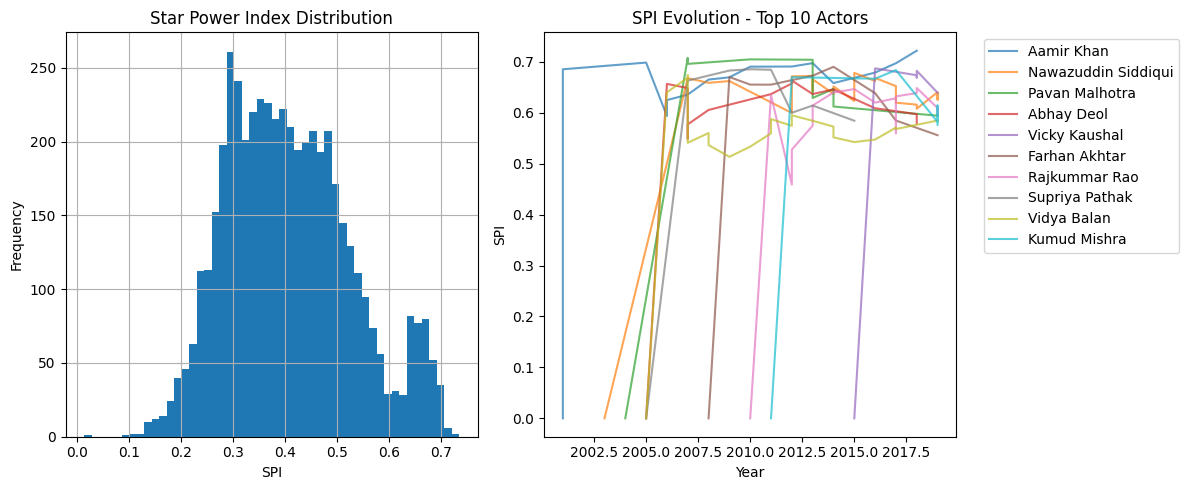

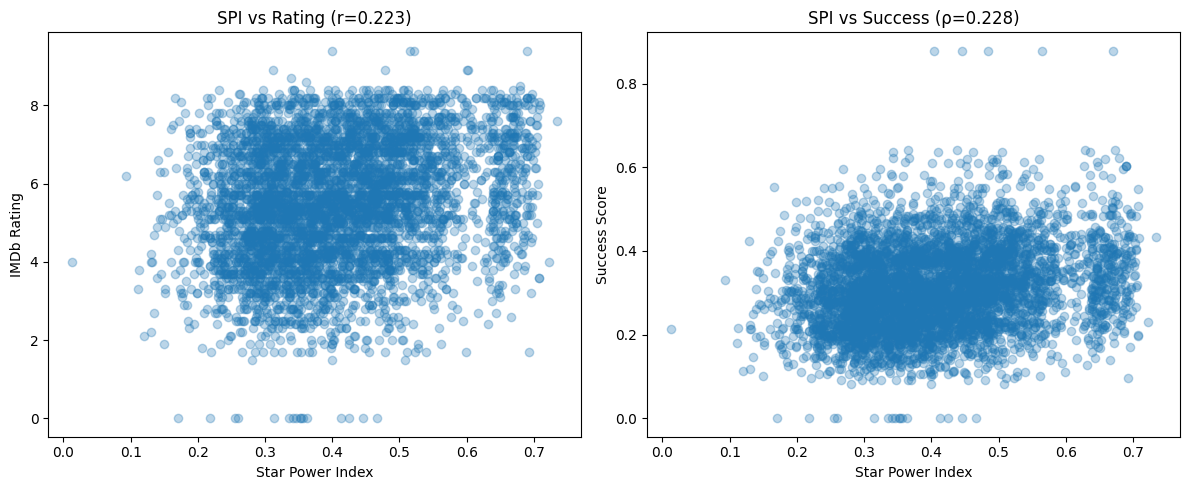

In [ ]:
# CELL 4: SPI distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
df_with_spi[df_with_spi['SPI'] > 0]['SPI'].hist(bins=50)
plt.title('Star Power Index Distribution')
plt.xlabel('SPI')
plt.ylabel('Frequency')
plt.subplot(1, 2, 2)
# Top 10 actors SPI over time
top_10 = df_with_spi.groupby('actor_name')['SPI'].mean().nlargest(10).index
for actor in top_10:
 actor_data = df_with_spi[df_with_spi['actor_name'] == actor].sort_values('year_of_release')
 plt.plot(actor_data['year_of_release'], actor_data['SPI'], label=actor, alpha=0.7)
plt.title('SPI Evolution - Top 10 Actors')
plt.xlabel('Year')
plt.ylabel('SPI')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('spi_validation.png', dpi=300, bbox_inches='tight')

#CELL 5
# Key question: Does higher SPI lead to more successful movies?
# Filter to movies where actors have SPI (not debut)
df_analysis = df_with_spi[df_with_spi['SPI'] > 0].copy()
# Correlation analysis
from scipy.stats import pearsonr, spearmanr
corr_rating, p_rating = pearsonr(
 df_analysis['SPI'].dropna(),
 df_analysis['imdb_rating'].dropna()
)
corr_success, p_success = spearmanr(
 df_analysis['SPI'].dropna(),
 df_analysis['movie_success_score'].dropna()
)
print("\n=== CORRELATION ANALYSIS ===")
print(f"SPI vs IMDb Rating: r={corr_rating:.3f}, p={p_rating:.4f}")
print(f"SPI vs Success Score: ρ={corr_success:.3f}, p={p_success:.4f}")
# Scatter plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(df_analysis['SPI'], df_analysis['imdb_rating'], alpha=0.3)
plt.xlabel('Star Power Index')
plt.ylabel('IMDb Rating')
plt.title(f'SPI vs Rating (r={corr_rating:.3f})')
plt.subplot(1, 2, 2)
plt.scatter(df_analysis['SPI'], df_analysis['movie_success_score'], alpha=0.3)
plt.xlabel('Star Power Index')
plt.ylabel('Success Score')
plt.title(f'SPI vs Success (ρ={corr_success:.3f})')
plt.tight_layout()
plt.savefig('spi_correlation.png', dpi=300, bbox_inches='tight')

#CELL 6

def aggregate_spi_to_movie(df_with_spi):
    """
    For each movie, calculate aggregate cast SPI
    Weighted by role position (lead = 50%, second = 30%, third = 20%)
    """

    # Keep top 3 actors per movie
    df_top3 = df_with_spi[df_with_spi['role_position'] <= 3].copy()

    # Position weights
    position_weights = {1: 0.5, 2: 0.3, 3: 0.2}
    df_top3['position_weight'] = df_top3['role_position'].map(position_weights)

    movie_spi = []

    for movie_id in df_top3['movie_id'].unique():
        movie_cast = df_top3[df_top3['movie_id'] == movie_id]

        # Weighted average SPI
        valid = movie_cast[['SPI', 'position_weight']].dropna()

        if len(valid) > 0:
            weighted_spi = (valid['SPI'] * valid['position_weight']).sum() / valid['position_weight'].sum()
        else:
            weighted_spi = np.nan

        # Lead actor SPI (role_position == 1)
        lead_spi = np.nan
        lead_rows = movie_cast[movie_cast['role_position'] == 1]
        if len(lead_rows) > 0:
            lead_spi = lead_rows['SPI'].values[0]

        movie_spi.append({
            'movie_id': movie_id,
            'movie_cast_SPI': weighted_spi,
            'cast_size': len(movie_cast),
            'lead_actor_SPI': lead_spi,
            'max_cast_SPI': movie_cast['SPI'].max(),
            'min_cast_SPI': movie_cast['SPI'].min()
        })

    return pd.DataFrame(movie_spi)

movie_spi_df = aggregate_spi_to_movie(df_with_spi)

print("\nMovie-Level SPI Summary:")
print(movie_spi_df.describe())


#CELL 7

# Save actor-level SPI
df_with_spi.to_csv('bollywood_actor_features_with_spi.csv', index=False)
print("✓ Saved: bollywood_actor_features_with_spi.csv")
# Save movie-level SPI
movie_spi_df.to_csv('bollywood_movie_spi.csv', index=False)
print("✓ Saved: bollywood_movie_spi.csv")
# Save top actors ranking
top_actors_df = df_with_spi.groupby('actor_name').agg({
 'SPI': 'mean',
 'movie_id': 'count',
 'career_movies_count': 'max',
 'career_avg_rating': 'mean',
 'career_hit_ratio': 'mean'
}).reset_index()
top_actors_df.columns = ['actor_name', 'avg_SPI', 'movies_in_dataset', 'total_career_movies', 'avg_rating', 'hit_ratio']
top_actors_df = top_actors_df.sort_values('avg_SPI', ascending=False)
top_actors_df.to_csv('bollywood_actor_rankings.csv', index=False)
print("✓ Saved: bollywood_actor_rankings.csv")


# CELL 8 - FINAL ANALYSIS AND INSIGHTS

# Example: Genre analysis
genre_analysis = df_with_spi.groupby('primary_genre').agg({
 'SPI': 'mean',
 'movie_success_score': 'mean',
 'imdb_rating': 'mean'
}).reset_index()
print("\nStar Power by Genre:")
print(genre_analysis.sort_values('SPI', ascending=False))
# Example: Regression analysis
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
# Prepare data
X = df_analysis[['SPI', 'years_in_industry', 'genre_diversity']].fillna(0)
y = df_analysis['movie_success_score']
# Split and train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model = LinearRegression()
model.fit(X_train, y_train)
print(f"\nRegression R²: {model.score(X_test, y_test):.3f}")
print("Feature Importance:")
for feature, coef in zip(X.columns, model.coef_):
 print(f" {feature}: {coef:.4f}")

In [ ]:
# jahnavi
# === MY DATA LOADING CELL (DO NOT TOUCH ANY OTHER CELLS) ===

# === STEP 1: load & merge data (run in Google Colab) ===
import os
import sys
import pandas as pd

# filenames we expect
expected_files = {
    "movies": "bollywood_movies_with_cast.csv",
    "actor_spi": "bollywood_actor_features_with_spi.csv",
    "movie_spi": "bollywood_movie_spi.csv",
    "actor_rankings": "bollywood_actor_rankings.csv"
}

print("Checking for expected files in /content and /mnt/data ...\n")
files_found = []
for root in ("/content", "/mnt/data", "."):
    try:
        for fname in os.listdir(root):
            if fname.endswith(".csv"):
                files_found.append(os.path.join(root, fname))
    except Exception:
        pass

# show discovered CSVs (helpful)
print("Discovered CSV files (first 200 chars shown per path):")
for p in files_found:
    print(" -", p)
print("\n")

# helper to read a CSV, with fallback to upload if missing
def read_csv_with_prompt(key, fname):
    from pathlib import Path
    path_candidates = [
        os.path.join("/content", fname),
        os.path.join("/mnt/data", fname),
        fname,
    ]
    for p in path_candidates:
        if os.path.exists(p):
            try:
                df = pd.read_csv(p)
                print(f"Loaded '{fname}' from: {p}   (shape={df.shape})")
                return df
            except Exception as e:
                print(f"Found file {p} but failed to read it: {e}")
                break

    # If not found or failed, prompt upload (Colab)
    print(f"File '{fname}' not found in working paths. Please upload it now (or place it in /content or /mnt/data).")
    try:
        from google.colab import files
        uploaded = files.upload()
        # try to find our file among uploaded
        if fname in uploaded:
            df = pd.read_csv(fname)
            print(f"Uploaded and loaded '{fname}' (shape={df.shape})")
            return df
        else:
            # if user uploaded with different filename, try to load any uploaded csv with similar name
            for upname in uploaded:
                if upname.lower().startswith(fname.split('.')[0].lower()):
                    try:
                        df = pd.read_csv(upname)
                        print(f"Loaded uploaded file '{upname}' for expected '{fname}' (shape={df.shape})")
                        return df
                    except Exception:
                        pass
            raise FileNotFoundError(f"Uploaded files did not include '{fname}'. Uploaded: {list(uploaded.keys())}")
    except Exception as e:
        raise FileNotFoundError(f"Could not find or upload '{fname}': {e}")

# Read all datasets
movies = read_csv_with_prompt("movies", expected_files["movies"])
actor_spi = read_csv_with_prompt("actor_spi", expected_files["actor_spi"])
movie_spi = read_csv_with_prompt("movie_spi", expected_files["movie_spi"])
actor_rankings = read_csv_with_prompt("actor_rankings", expected_files["actor_rankings"])

# Quick inspections
print("\n--- Quick inspections ---\n")
print("movies.columns:", list(movies.columns))
print("movie_spi.columns:", list(movie_spi.columns))
print("actor_spi.columns:", list(actor_spi.columns))
print("actor_rankings.columns:", list(actor_rankings.columns))
print("\nSample: movies.head():")
display(movies.head(3))
print("\nSample: movie_spi.head():")
display(movie_spi.head(3))
print("\nSample: actor_rankings.head():")
display(actor_rankings.head(3))

# Attempt merge: on 'movie_id' (common column per guide). If movie_id not present, try other common keys.
merge_on = "movie_id"
if merge_on not in movies.columns or merge_on not in movie_spi.columns:
    # find intersection of column names
    common = set(movies.columns).intersection(set(movie_spi.columns))
    print(f"\nWarning: '{merge_on}' not present in both tables. Common columns are: {common}")
    if common:
        merge_on = list(common)[0]
        print(f"Will try merging on '{merge_on}' instead.")
    else:
        raise KeyError("No common columns found between movies and movie_spi. Please check column names.")

# perform left merge (preserve movies)
movies_analysis = movies.merge(movie_spi, how="left", on=merge_on, suffixes=('', '_spi'))

# Basic merged diagnostics
print("\n=== Merge diagnostics ===")
print("movies.shape:", movies.shape)
print("movie_spi.shape:", movie_spi.shape)
print("merged (movies_analysis).shape:", movies_analysis.shape)

# Identify likely SPI column names after merge
spi_candidates = [c for c in movies_analysis.columns if 'spi' in c.lower() or 'movie_cast_spi' in c.lower()]
print("Potential SPI-related columns in merged frame:", spi_candidates)

# Count how many movies have non-null SPI (using any SPI column if present)
non_null_spi = 0
if spi_candidates:
    # choose first candidate
    spi_col = spi_candidates[0]
    non_null_spi = movies_analysis[spi_col].notnull().sum()
    print(f"Using '{spi_col}' as SPI column -> movies with non-null SPI: {non_null_spi} / {len(movies_analysis)}")
else:
    print("No SPI-looking column detected in merged dataframe. Please check column names.")

# Save merged file for convenience
outpath = "/content/movies_analysis.csv"
movies_analysis.to_csv(outpath, index=False)
print(f"\nSaved merged dataframe to: {outpath}")

# Print a compact summary for you to paste back here
summary = {
    "movies.shape": movies.shape,
    "movie_spi.shape": movie_spi.shape,
    "actor_spi.shape": actor_spi.shape,
    "actor_rankings.shape": actor_rankings.shape,
    "merged.shape": movies_analysis.shape,
    "movies_with_spi_nonnull": non_null_spi,
    "spi_column_used": spi_candidates[0] if spi_candidates else None,
    "merged_saved_to": outpath
}
print("\n--- COPY/PASTE this summary (or the printed output above) back here so I can give you the next step ---")
print(summary)


Checking for expected files in /content and /mnt/data ...

Discovered CSV files (first 200 chars shown per path):
 - /content/movies_clean.csv
 - /content/bollywood_movie_spi.csv
 - /content/bollywood_actor_features.csv
 - /content/bollywood_actor_features_with_spi.csv
 - /content/movies.csv
 - /content/bollywood_actor_rankings.csv
 - ./movies_clean.csv
 - ./bollywood_movie_spi.csv
 - ./bollywood_actor_features.csv
 - ./bollywood_actor_features_with_spi.csv
 - ./movies.csv
 - ./bollywood_actor_rankings.csv


File 'bollywood_movies_with_cast.csv' not found in working paths. Please upload it now (or place it in /content or /mnt/data).


Saving bollywood_movies_with_cast.csv to bollywood_movies_with_cast.csv
Uploaded and loaded 'bollywood_movies_with_cast.csv' (shape=(1619, 44))
Loaded 'bollywood_actor_features_with_spi.csv' from: /content/bollywood_actor_features_with_spi.csv   (shape=(7574, 36))
Loaded 'bollywood_movie_spi.csv' from: /content/bollywood_movie_spi.csv   (shape=(1619, 6))
Loaded 'bollywood_actor_rankings.csv' from: /content/bollywood_actor_rankings.csv   (shape=(2556, 6))

--- Quick inspections ---

movies.columns: ['movie_id', 'title_x', 'year_of_release', 'release_date_parsed', 'release_country', 'imdb_rating', 'imdb_votes', 'runtime', 'primary_genre', 'genres_list', 'num_genres', 'wins', 'nominations', 'total_recognitions', 'actors_list', 'num_actors', 'lead_actor_1', 'lead_actor_2', 'lead_actor_3', 'lead_actor_4', 'lead_actor_5', 'movie_success_score', 'is_hit', 'story', 'summary', 'tagline', 'cast_career_movies_count', 'cast_career_avg_rating', 'cast_career_total_votes', 'cast_career_hit_ratio', 'c

,movie_id,title_x,year_of_release,release_date_parsed,release_country,imdb_rating,imdb_votes,runtime,primary_genre,genres_list,...,cast_movies_last_2_years,cast_peak_rating,cast_peak_success_score,cast_genre_diversity,cast_lead_role_ratio,cast_size_top3,cast_total_experience,cast_max_experience,cast_has_veteran,cast_has_newcomer
0,MOV_00000,Uri: The Surgical Strike,2019,2019-01-11,USA,8.4,35112.0,138.0,Action,"['Action', 'Drama', 'War']",...,3.2,8.1375,0.519327,4.8,0.136275,3,57,51,1,1
1,MOV_00001,Battalion 609,2019,2019-01-11,India,4.1,73.0,131.0,War,['War'],...,0.0,7.1000,0.413979,2.0,0.250000,3,4,4,0,1
2,MOV_00002,The Accidental Prime Minister (film),2019,2019-01-11,USA,6.1,5549.0,112.0,Biography,"['Biography', 'Drama']",...,2.0,7.9400,0.499521,5.6,0.287302,3,83,63,1,1



Sample: movie_spi.head():


,movie_id,movie_cast_SPI,cast_size,lead_actor_SPI,max_cast_SPI,min_cast_SPI
0,MOV_01591,0.259687,3,0.334536,0.334536,0.0
1,MOV_00217,0.000000,3,0.000000,0.000000,0.0
2,MOV_00550,0.000000,3,0.000000,0.000000,0.0



Sample: actor_rankings.head():


,actor_name,avg_SPI,movies_in_dataset,total_career_movies,avg_rating,hit_ratio
0,Aamir Khan,0.627249,15,14,7.707265,0.851846
1,Nawazuddin Siddiqui,0.623706,28,27,7.311833,0.771645
2,Pavan Malhotra,0.588429,9,8,7.869405,0.871577



=== Merge diagnostics ===
movies.shape: (1619, 44)
movie_spi.shape: (1619, 6)
merged (movies_analysis).shape: (1619, 49)
Potential SPI-related columns in merged frame: ['movie_cast_SPI', 'lead_actor_SPI', 'max_cast_SPI', 'min_cast_SPI']
Using 'movie_cast_SPI' as SPI column -> movies with non-null SPI: 1619 / 1619

Saved merged dataframe to: /content/movies_analysis.csv

--- COPY/PASTE this summary (or the printed output above) back here so I can give you the next step ---
{'movies.shape': (1619, 44), 'movie_spi.shape': (1619, 6), 'actor_spi.shape': (7574, 36), 'actor_rankings.shape': (2556, 6), 'merged.shape': (1619, 49), 'movies_with_spi_nonnull': np.int64(1619), 'spi_column_used': 'movie_cast_SPI', 'merged_saved_to': '/content/movies_analysis.csv'}


In [ ]:
# === STEP 2: Load merged dataset & setup visualization environment ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Load merged data
movies_analysis = pd.read_csv("/content/movies_analysis.csv")
print("Loaded merged dataset:", movies_analysis.shape)

# Head preview
display(movies_analysis.head())

# Set clean styles
plt.style.use("default")
sns.set_theme(style="whitegrid", palette="deep")

print("\nVisualization libraries ready.")


Loaded merged dataset: (1619, 49)


,movie_id,title_x,year_of_release,release_date_parsed,release_country,imdb_rating,imdb_votes,runtime,primary_genre,genres_list,...,cast_size_top3,cast_total_experience,cast_max_experience,cast_has_veteran,cast_has_newcomer,movie_cast_SPI,cast_size,lead_actor_SPI,max_cast_SPI,min_cast_SPI
0,MOV_00000,Uri: The Surgical Strike,2019,2019-01-11,USA,8.4,35112.0,138.0,Action,"['Action', 'Drama', 'War']",...,3,57,51,1,1,0.506420,3,0.639308,0.639308,0.000000
1,MOV_00001,Battalion 609,2019,2019-01-11,India,4.1,73.0,131.0,War,['War'],...,3,4,4,0,1,0.205018,3,0.410036,0.410036,0.000000
2,MOV_00002,The Accidental Prime Minister (film),2019,2019-01-11,USA,6.1,5549.0,112.0,Biography,"['Biography', 'Drama']",...,3,83,63,1,1,0.525442,3,0.621470,0.621470,0.347405
3,MOV_00003,Why Cheat India,2019,2019-01-18,USA,6.0,1891.0,121.0,Crime,"['Crime', 'Drama']",...,3,32,32,1,1,0.239608,3,0.479216,0.479216,0.000000
4,MOV_00004,Evening Shadows,2018,2019-01-11,India,7.3,280.0,102.0,Drama,['Drama'],...,3,5,2,0,1,0.376708,3,0.426380,0.426380,0.301827



Visualization libraries ready.


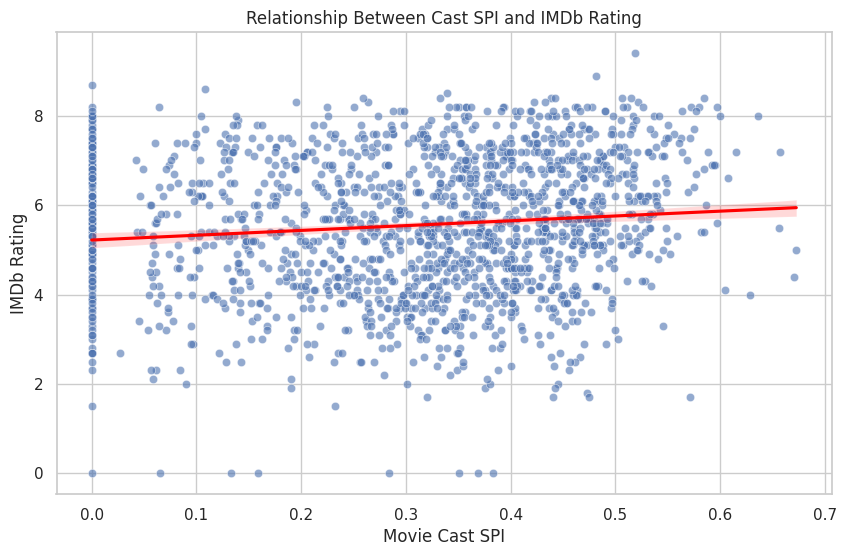

In [ ]:
# === STEP 3: Scatter plot - Movie SPI vs IMDb Rating ===

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=movies_analysis,
    x="movie_cast_SPI",
    y="imdb_rating",
    alpha=0.6
)
sns.regplot(
    data=movies_analysis,
    x="movie_cast_SPI",
    y="imdb_rating",
    scatter=False,
    color="red"
)
plt.title("Relationship Between Cast SPI and IMDb Rating")
plt.xlabel("Movie Cast SPI")
plt.ylabel("IMDb Rating")
plt.show()


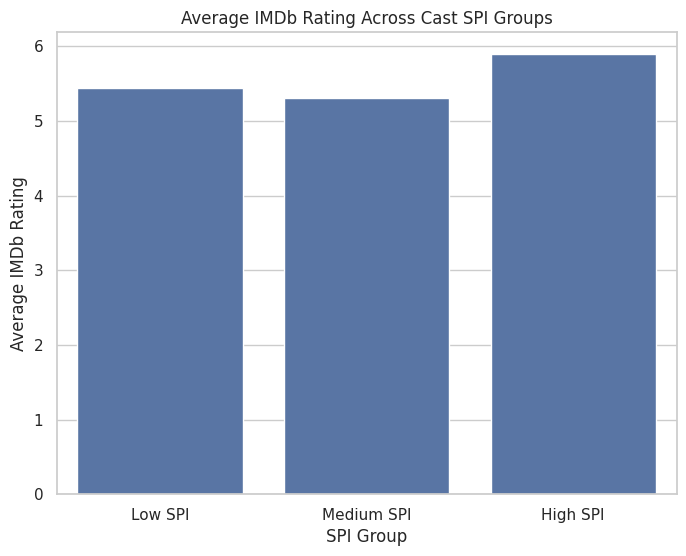

,imdb_rating
SPI_group,
Low SPI,5.442037
Medium SPI,5.310761
High SPI,5.894259


In [ ]:
# === STEP 4: IMDb rating across SPI groups (Low / Medium / High) ===

# Create SPI categories
movies_analysis["SPI_group"] = pd.qcut(
    movies_analysis["movie_cast_SPI"],
    q=3,
    labels=["Low SPI", "Medium SPI", "High SPI"]
)

plt.figure(figsize=(8,6))
sns.barplot(
    data=movies_analysis,
    x="SPI_group",
    y="imdb_rating",
    estimator="mean",
    ci=None
)

plt.title("Average IMDb Rating Across Cast SPI Groups")
plt.xlabel("SPI Group")
plt.ylabel("Average IMDb Rating")
plt.show()

# Show actual averages for the report
movies_analysis.groupby("SPI_group")["imdb_rating"].mean()


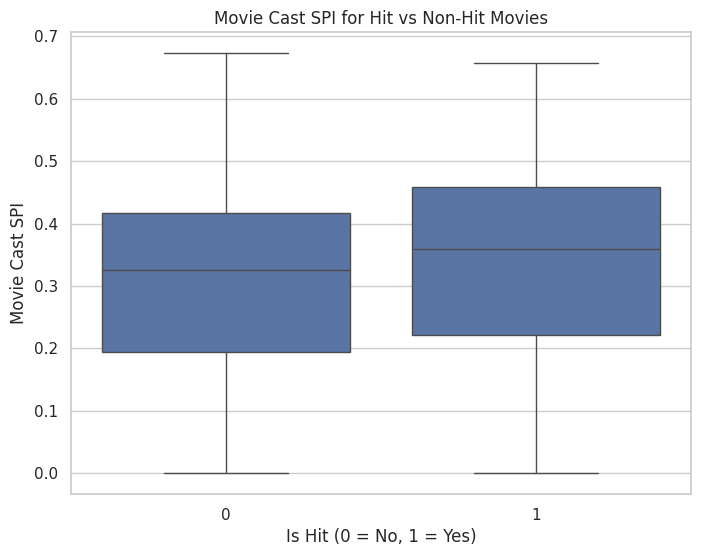

,movie_cast_SPI
is_hit,
0,0.298705
1,0.333040


In [ ]:
# === STEP 5: Compare Movie SPI for Hit vs Non-Hit Movies ===

plt.figure(figsize=(8,6))
sns.boxplot(
    data=movies_analysis,
    x="is_hit",
    y="movie_cast_SPI"
)
plt.title("Movie Cast SPI for Hit vs Non-Hit Movies")
plt.xlabel("Is Hit (0 = No, 1 = Yes)")
plt.ylabel("Movie Cast SPI")
plt.show()

# Show numeric averages for your report
movies_analysis.groupby("is_hit")["movie_cast_SPI"].mean()


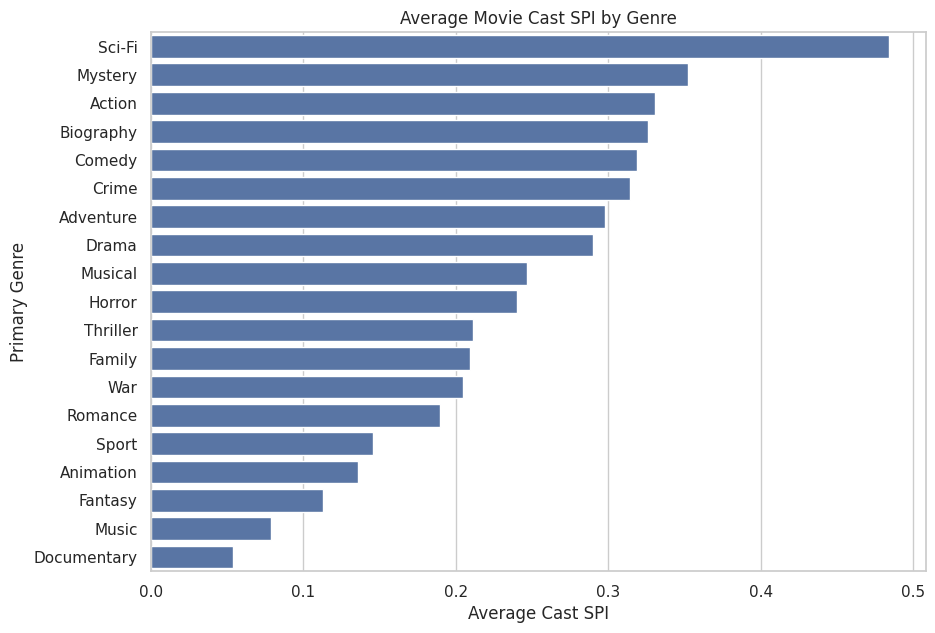

,movie_cast_SPI
primary_genre,
Sci-Fi,0.484012
Mystery,0.352328
Action,0.330984
Biography,0.325876
Comedy,0.319047
Crime,0.314487
Adventure,0.297620
Drama,0.289789
Musical,0.246621


In [ ]:
# === STEP 6: Genre-wise Average SPI ===

genre_spi = (
    movies_analysis.groupby("primary_genre")["movie_cast_SPI"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,7))
sns.barplot(
    x=genre_spi.values,
    y=genre_spi.index
)
plt.title("Average Movie Cast SPI by Genre")
plt.xlabel("Average Cast SPI")
plt.ylabel("Primary Genre")
plt.show()

genre_spi


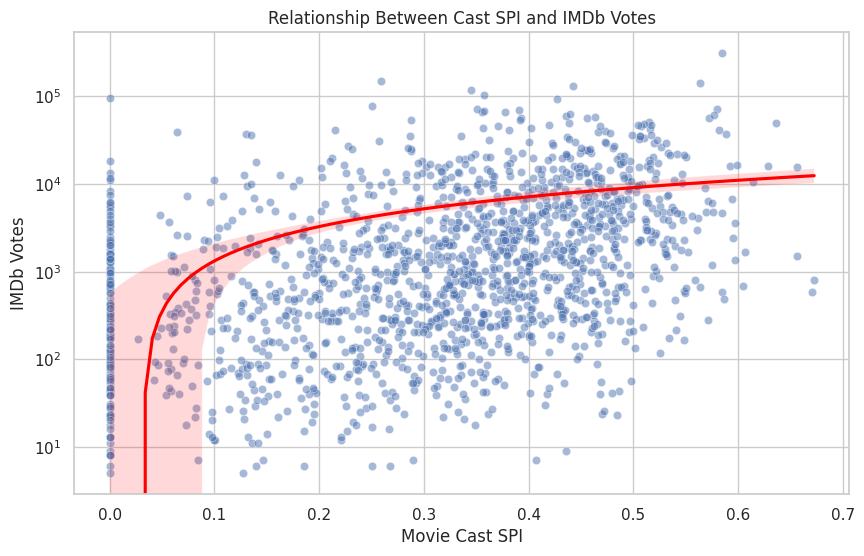

np.float64(0.21317299167235168)

In [ ]:
# === STEP 7: Scatter Plot - SPI vs IMDb Votes ===

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=movies_analysis,
    x="movie_cast_SPI",
    y="imdb_votes",
    alpha=0.5
)
sns.regplot(
    data=movies_analysis,
    x="movie_cast_SPI",
    y="imdb_votes",
    scatter=False,
    color="red"
)

plt.title("Relationship Between Cast SPI and IMDb Votes")
plt.xlabel("Movie Cast SPI")
plt.ylabel("IMDb Votes")
plt.yscale("log")  # log scale because vote counts vary a lot
plt.show()

# Correlation value (quantitative insight)
movies_analysis["movie_cast_SPI"].corr(movies_analysis["imdb_votes"])


In [ ]:
# === STEP 8: Top 20 Movies by Cast SPI ===

top_20_spi_movies = movies_analysis[[
    "movie_id",
    "title_x",
    "year_of_release",
    "movie_cast_SPI",
    "imdb_rating",
    "is_hit"
]].sort_values(by="movie_cast_SPI", ascending=False).head(20)

display(top_20_spi_movies)


,movie_id,title_x,year_of_release,movie_cast_SPI,imdb_rating,is_hit
931,MOV_00932,Aa Dekhen Zara,2009,0.672727,5.0,0
1500,MOV_01504,Badhaai Ho Badhaai,2002,0.671029,4.4,0
211,MOV_00211,Toilet: Ek Prem Katha,2017,0.656730,7.2,1
372,MOV_00372,Hawaizaada,2015,0.656421,5.5,0
256,MOV_00256,Airlift (film),2016,0.636405,8.0,1
166,MOV_00166,Thugs of Hindostan,2018,0.628593,4.0,0
296,MOV_00296,Te3n,2016,0.614755,7.2,1
49,MOV_00049,The Sky Is Pink,2019,0.607082,6.6,0
461,MOV_00461,One by Two (2014 film),2014,0.604539,4.1,0
429,MOV_00429,Manjhi – The Mountain Man,2015,0.599435,8.0,1


Top 20 actors by avg_SPI (first 20 rows):


,actor_name,avg_SPI,movies_in_dataset,total_career_movies,hit_ratio
0,Aamir Khan,0.627249,15,14,0.851846
1,Nawazuddin Siddiqui,0.623706,28,27,0.771645
2,Pavan Malhotra,0.588429,9,8,0.871577
3,Abhay Deol,0.575952,14,13,0.797634
4,Vicky Kaushal,0.575138,7,6,0.972222
5,Farhan Akhtar,0.569264,9,8,0.896577
6,Rajkummar Rao,0.568177,19,18,0.733357
7,Supriya Pathak,0.564373,8,7,0.906803
8,Vidya Balan,0.550164,22,21,0.618972
9,Kumud Mishra,0.541920,7,6,0.869444


Saved /content/top_actors.csv


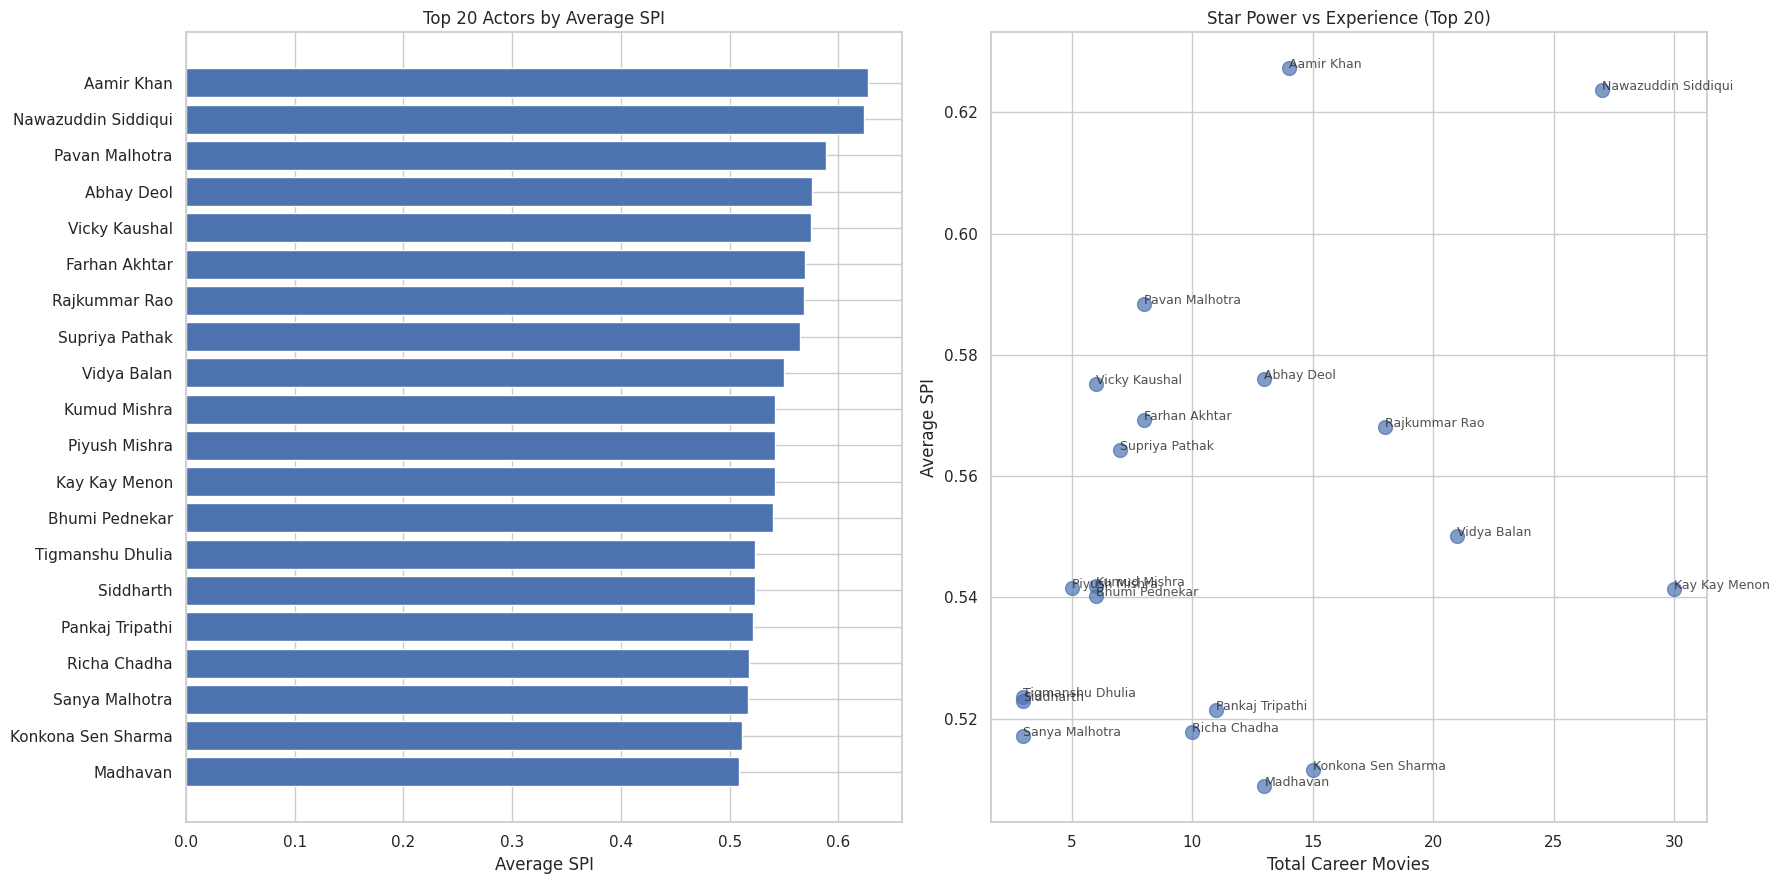

Saved /content/actor_analysis.png


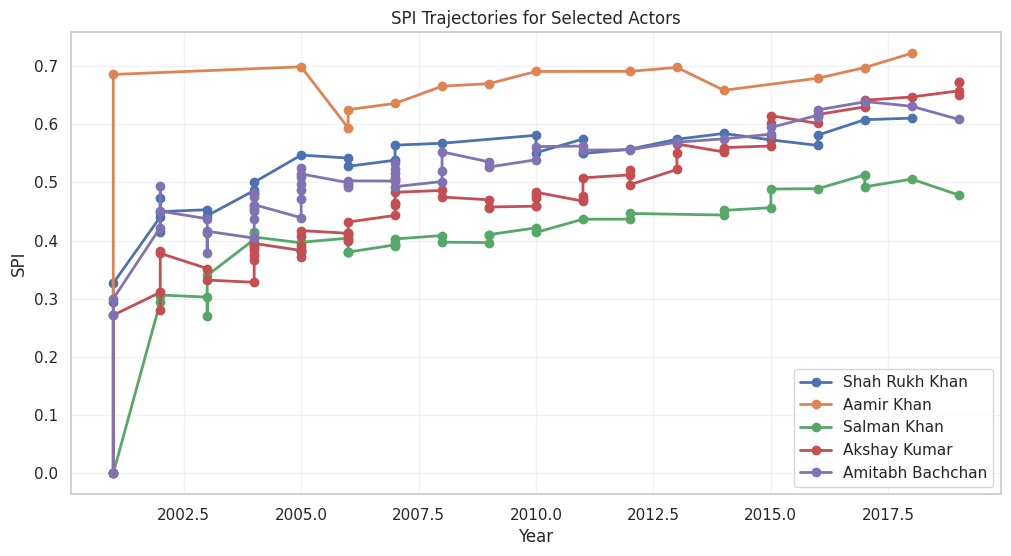

Saved /content/actor_trajectories.png


In [ ]:
# === STEP 9: Actor-level analysis (Top actors + trajectories) ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load actor ranking and actor SPI (we loaded movies_analysis earlier)
actor_rankings = pd.read_csv("/content/bollywood_actor_rankings.csv")
actor_spi = pd.read_csv("/content/bollywood_actor_features_with_spi.csv")

# Top 20 actors by average SPI
top20_actors = actor_rankings.sort_values("avg_SPI", ascending=False).head(20).reset_index(drop=True)

print("Top 20 actors by avg_SPI (first 20 rows):")
display(top20_actors[["actor_name", "avg_SPI", "movies_in_dataset", "total_career_movies", "hit_ratio"]])

# Save top actors
top20_actors.to_csv("/content/top_actors.csv", index=False)
print("Saved /content/top_actors.csv")

# Plot: Top 20 bar chart + scatter (career movies vs avg_SPI)
fig, axes = plt.subplots(1, 2, figsize=(18,9))
# barh
axes[0].barh(top20_actors["actor_name"][::-1], top20_actors["avg_SPI"][::-1])
axes[0].set_title("Top 20 Actors by Average SPI")
axes[0].set_xlabel("Average SPI")
# scatter
axes[1].scatter(top20_actors["total_career_movies"], top20_actors["avg_SPI"], s=100, alpha=0.7)
for i, row in top20_actors.iterrows():
    axes[1].annotate(row["actor_name"], (row["total_career_movies"], row["avg_SPI"]), fontsize=9, alpha=0.8)
axes[1].set_xlabel("Total Career Movies")
axes[1].set_ylabel("Average SPI")
axes[1].set_title("Star Power vs Experience (Top 20)")
plt.tight_layout()
plt.savefig("/content/actor_analysis.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved /content/actor_analysis.png")

# SPI trajectories for selected big stars if available
selected_actors = ["Shah Rukh Khan", "Aamir Khan", "Salman Khan", "Akshay Kumar", "Amitabh Bachchan"]
available = [a for a in selected_actors if a in actor_spi["actor_name"].unique()]
if not available:
    print("None of the selected famous actors found in actor SPI dataset. Showing top 3 available instead.")
    available = top20_actors["actor_name"].head(3).tolist()

plt.figure(figsize=(12,6))
for actor in available:
    adf = actor_spi[actor_spi["actor_name"] == actor].sort_values("year_of_release")
    if len(adf)==0:
        continue
    plt.plot(adf["year_of_release"], adf["SPI"], marker='o', linewidth=2, label=actor)
plt.xlabel("Year")
plt.ylabel("SPI")
plt.title("SPI Trajectories for Selected Actors")
plt.legend()
plt.grid(alpha=0.25)
plt.savefig("/content/actor_trajectories.png", dpi=200, bbox_inches="tight")
plt.show()
print("Saved /content/actor_trajectories.png")


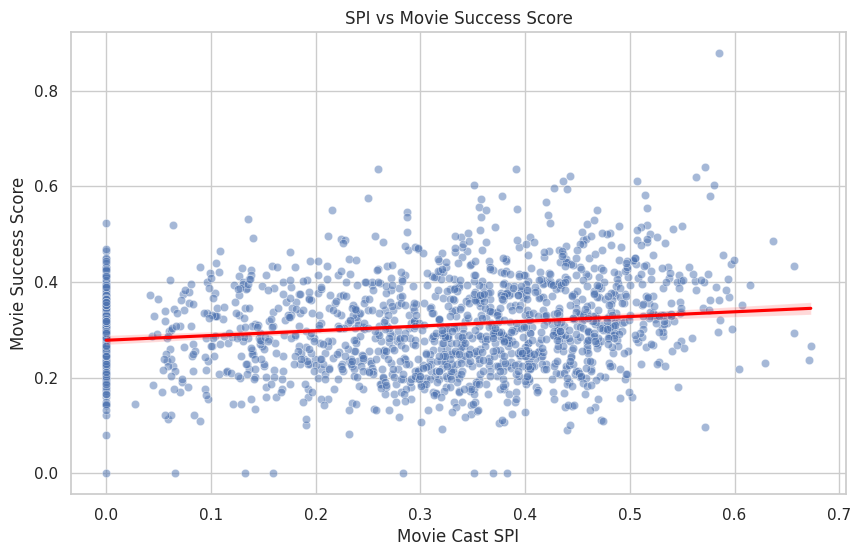

np.float64(0.1586763755170259)

In [ ]:
# === STEP 10: SPI vs Movie Success Score ===

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=movies_analysis,
    x="movie_cast_SPI",
    y="movie_success_score",
    alpha=0.5
)
sns.regplot(
    data=movies_analysis,
    x="movie_cast_SPI",
    y="movie_success_score",
    scatter=False,
    color="red"
)

plt.title("SPI vs Movie Success Score")
plt.xlabel("Movie Cast SPI")
plt.ylabel("Movie Success Score")
plt.show()

corr_spi_success = movies_analysis["movie_cast_SPI"].corr(movies_analysis["movie_success_score"])
corr_spi_success


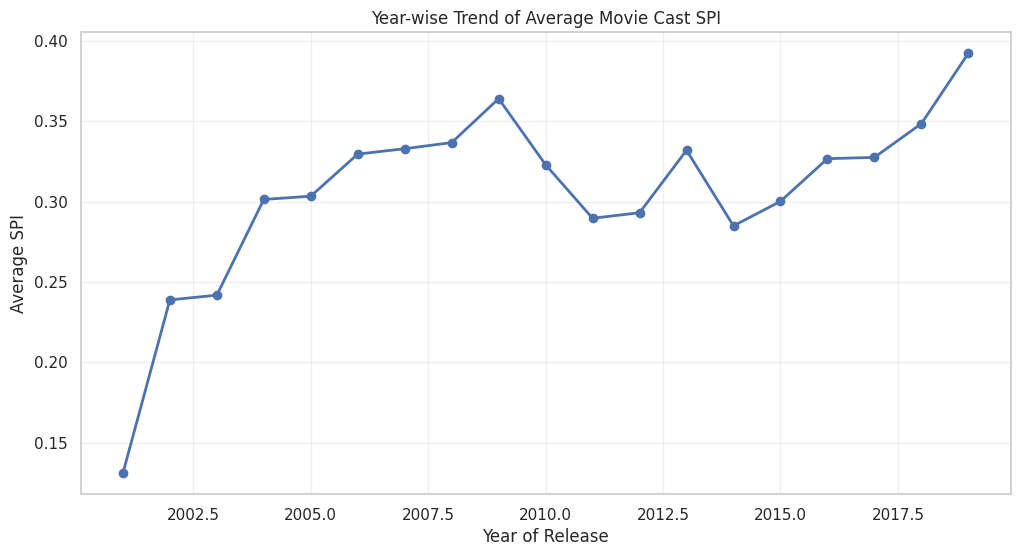

,year_of_release,movie_cast_SPI
0,2001,0.130963
1,2002,0.238864
2,2003,0.241811
3,2004,0.301393
4,2005,0.303424
5,2006,0.329621
6,2007,0.332972
7,2008,0.336784
8,2009,0.364112
9,2010,0.322977


In [ ]:
# === STEP 11: Year-wise Average SPI Trend ===

year_spi = (
    movies_analysis.groupby("year_of_release")["movie_cast_SPI"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))
plt.plot(
    year_spi["year_of_release"],
    year_spi["movie_cast_SPI"],
    marker="o",
    linewidth=2
)

plt.title("Year-wise Trend of Average Movie Cast SPI")
plt.xlabel("Year of Release")
plt.ylabel("Average SPI")
plt.grid(alpha=0.3)
plt.show()

year_spi


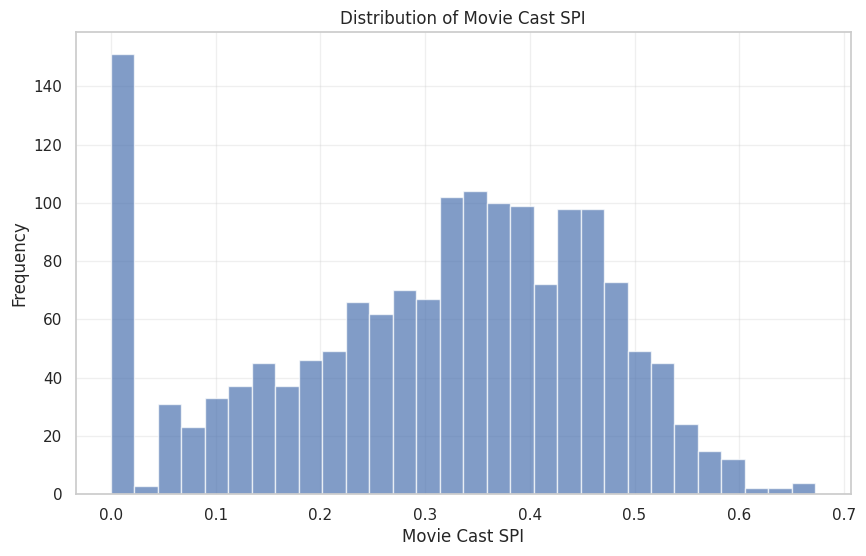

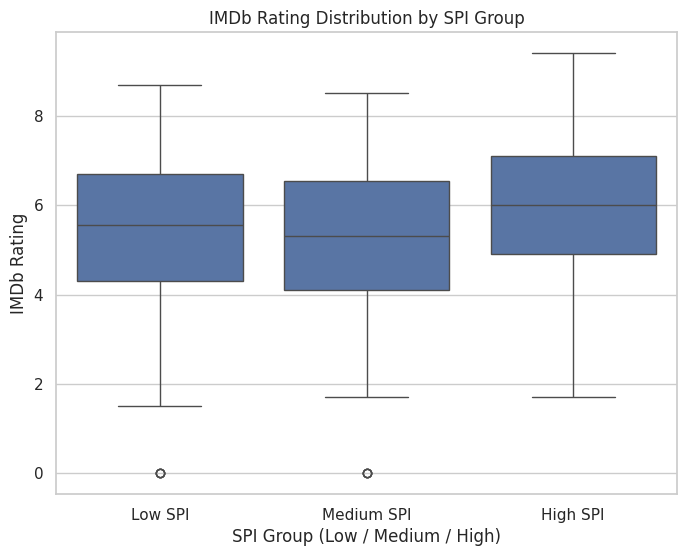

In [ ]:
# === STEP 12: SPI Distribution + Rating by SPI Group ===

# 1. Histogram of SPI
plt.figure(figsize=(10,6))
plt.hist(movies_analysis["movie_cast_SPI"], bins=30, alpha=0.7)
plt.title("Distribution of Movie Cast SPI")
plt.xlabel("Movie Cast SPI")
plt.ylabel("Frequency")
plt.grid(alpha=0.3)
plt.show()

# 2. Boxplot: IMDb Rating by SPI Group
plt.figure(figsize=(8,6))
sns.boxplot(
    data=movies_analysis,
    x="SPI_group",
    y="imdb_rating"
)
plt.title("IMDb Rating Distribution by SPI Group")
plt.xlabel("SPI Group (Low / Medium / High)")
plt.ylabel("IMDb Rating")
plt.show()


In [ ]:
# === STEP 13: Export Final Summary Tables ===

# 1. Top 30 movies by SPI
top_movies_by_spi = movies_analysis[[
    "movie_id", "title_x", "year_of_release",
    "movie_cast_SPI", "imdb_rating", "is_hit"
]].sort_values(by="movie_cast_SPI", ascending=False).head(30)

top_movies_by_spi.to_csv("/content/top_movies_by_spi.csv", index=False)
print("Saved: /content/top_movies_by_spi.csv")

# 2. Genre SPI summary
genre_spi_summary = (
    movies_analysis.groupby("primary_genre")["movie_cast_SPI"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

genre_spi_summary.to_csv("/content/genre_spi_summary.csv", index=False)
print("Saved: /content/genre_spi_summary.csv")

# 3. Year-wise SPI trend
spi_year_trend = (
    movies_analysis.groupby("year_of_release")["movie_cast_SPI"]
    .mean()
    .reset_index()
)

spi_year_trend.to_csv("/content/spi_year_trend.csv", index=False)
print("Saved: /content/spi_year_trend.csv")

print("\nAll required tables exported successfully.")


Saved: /content/top_movies_by_spi.csv
Saved: /content/genre_spi_summary.csv
Saved: /content/spi_year_trend.csv

All required tables exported successfully.


In [ ]:
import csv

paths = [
    "/content/bollywood_movies_with_cast.csv",
    "/content/bollywood_actor_features_with_spi.csv",
    "/content/bollywood_movie_spi.csv",
    "/content/bollywood_actor_rankings.csv"
]

for p in paths:
    try:
        with open(p, 'r', encoding='utf-8') as f:
            sample = f.readline()
            sniffer = csv.Sniffer()
            dialect = sniffer.sniff(sample)
            print(f"{p} → delimiter detected:", repr(dialect.delimiter))
    except Exception as e:
        print(f"{p} → could not read:", e)


/content/bollywood_movies_with_cast.csv → delimiter detected: ','
/content/bollywood_actor_features_with_spi.csv → delimiter detected: ','
/content/bollywood_movie_spi.csv → delimiter detected: ','
/content/bollywood_actor_rankings.csv → delimiter detected: ','


✓ Saved: fig3_pie_variance.png

✅ All visualizations created successfully!


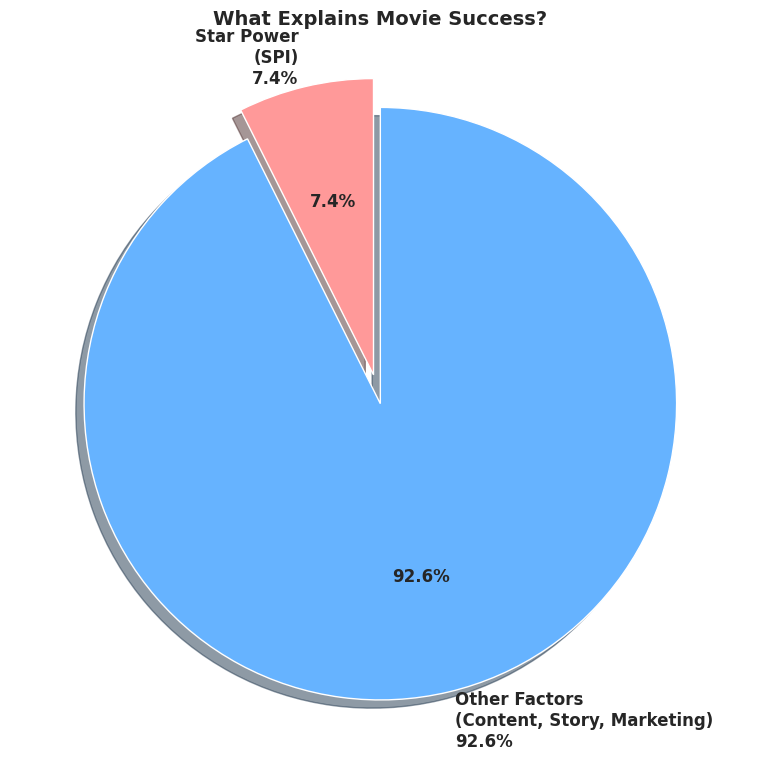

In [ ]:

fig, ax = plt.subplots(figsize=(8, 8))

sizes = [7.4, 92.6]
labels = ['Star Power\n(SPI)\n7.4%',
          'Other Factors\n(Content, Story, Marketing)\n92.6%']
colors = ['#ff9999', '#66b3ff']
explode = (0.1, 0)

ax.pie(sizes, explode=explode, labels=labels, colors=colors,
       autopct='%1.1f%%', shadow=True, startangle=90,
       textprops={'fontsize': 12, 'weight': 'bold'})
ax.set_title('What Explains Movie Success?', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('fig3_pie_variance.png', dpi=300, bbox_inches='tight')
print("✓ Saved: fig3_pie_variance.png")

print("\n✅ All visualizations created successfully!")